In [ ]:
%pip install matplotlib seaborn pandas numpy

  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 526.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 899.4 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 1.1 MB/s eta 0:00:00a 0:00:010m
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]8/10 [matplotlib]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [ ]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

def load_and_process_data(file_path):
    """
    อ่านไฟล์ CSV, แปลงข้อมูล, แกะ JSON, และคำนวณ Latency/Tokens
    """
    print(f"Reading data from: {file_path}")
    df = pd.read_csv(file_path)

    # 1. Convert Timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp')

    # 2. Calculate Duration (Latency) based on time difference
    df['prev_timestamp'] = df['timestamp'].shift(1)
    df['duration_seconds'] = (df['timestamp'] - df['prev_timestamp']).dt.total_seconds()
    df['duration_seconds'] = df['duration_seconds'].fillna(0)

    # 3. Extract Agent Role & Estimate Tokens
    def extract_details(row):
        agent_role = "Unknown"
        prompt_tokens = 0
        completion_tokens = 0

        if row['name'] == 'litellm-completion':
            # Estimate Tokens (1 token approx 4 chars)
            if pd.notna(row['input']):
                prompt_tokens = len(str(row['input'])) / 4
            if pd.notna(row['output']):
                completion_tokens = len(str(row['output'])) / 4

            # Extract Role from JSON Input
            if pd.notna(row['input']):
                try:
                    data = json.loads(row['input'])
                    if isinstance(data, str): data = json.loads(data) # Double encoded check

                    if isinstance(data, dict) and 'messages' in data:
                        for msg in data['messages']:
                            if msg.get('role') == 'system':
                                content = msg.get('content', '')
                                if "You are" in content:
                                    agent_role = content.split("You are")[1].split("\n")[0]
                                    agent_role = agent_role.replace("*", "").replace("#", "").strip()[:40]
                                break
                except:
                    pass

        return pd.Series([agent_role, prompt_tokens, completion_tokens])

    # Apply extraction
    df[['agent_role', 'est_prompt_tokens', 'est_completion_tokens']] = df.apply(extract_details, axis=1)
    df['est_total_tokens'] = df['est_prompt_tokens'] + df['est_completion_tokens']

    return df

def plot_visualizations(df):
    # Filter only LLM calls for most charts
    llm_df = df[df['name'] == 'litellm-completion'].copy()
    llm_df = llm_df[llm_df['agent_role'] != "Unknown"] # Filter out unknowns for cleaner plots

    # --- Graph 1: Timeline of Events ---
    plt.figure()
    plt.scatter(df['timestamp'], df['name'], alpha=0.6, color='teal')
    plt.title('1. Timeline of System Events')
    plt.xlabel('Time')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Graph 2: Agent Activity Distribution ---
    plt.figure()
    agent_counts = llm_df['agent_role'].value_counts()
    sns.barplot(y=agent_counts.index, x=agent_counts.values, palette='viridis')
    plt.title('2. Activity Distribution by Agent Persona (Count)')
    plt.xlabel('Number of Interactions')
    plt.tight_layout()
    plt.show()

    # --- Graph 3: Estimated Token Usage Over Time ---
    plt.figure()
    plt.plot(llm_df['timestamp'], llm_df['est_total_tokens'], marker='o', linestyle='-', color='purple')
    plt.title('3. Estimated Token Usage Over Time')
    plt.xlabel('Time')
    plt.ylabel('Estimated Tokens')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- Graph 4: Event Frequency (per Minute) ---
    plt.figure()
    df.set_index('timestamp').resample('1T').size().plot(kind='bar', color='skyblue')
    plt.title('4. Event Frequency (Events per Minute)')
    plt.xlabel('Time')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # --- Graph 5: Average Token Usage (Input vs Output) ---
    # Aggregate data
    role_avg = llm_df.groupby('agent_role')[['est_prompt_tokens', 'est_completion_tokens']].mean().reset_index()
    role_avg = role_avg.sort_values('est_prompt_tokens', ascending=False)

    plt.figure()
    # Stacked Bar Plot logic
    p1 = plt.bar(role_avg['agent_role'], role_avg['est_prompt_tokens'], label='Avg Input', color='#4c72b0')
    p2 = plt.bar(role_avg['agent_role'], role_avg['est_completion_tokens'], bottom=role_avg['est_prompt_tokens'], label='Avg Output', color='#dd8452')
    plt.title('5. Average Token Usage per Agent (Input vs Output)')
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Graph 6: Latency Distribution (Box Plot) ---
    plt.figure()
    sns.boxplot(x='agent_role', y='duration_seconds', data=llm_df, palette="Set3")
    plt.title('6. Latency (Duration) Distribution by Agent Role')
    plt.xticks(rotation=90)
    plt.ylabel('Duration (Seconds)')
    plt.tight_layout()
    plt.show()

    # --- Graph 7: Performance Scatter (Latency vs Load) ---
    role_stats = llm_df.groupby('agent_role').agg({
        'est_total_tokens': 'mean',
        'duration_seconds': ['mean', 'count']
    }).reset_index()
    role_stats.columns = ['agent_role', 'avg_tokens', 'avg_latency', 'count']

    plt.figure()
    sns.scatterplot(data=role_stats, x='avg_tokens', y='avg_latency', size='count', sizes=(100, 1000), hue='agent_role', legend=False)

    # Add labels
    for i, row in role_stats.iterrows():
        plt.text(row['avg_tokens'], row['avg_latency'], row['agent_role'], fontsize=8)

    plt.title('7. Agent Performance: Avg Latency vs Avg Token Load')
    plt.xlabel('Average Total Tokens')
    plt.ylabel('Average Latency (Seconds)')
    plt.tight_layout()
    plt.show()

    # --- Graph 8: Total Token Usage Ranking ---
    role_sums = llm_df.groupby('agent_role')['est_total_tokens'].sum().sort_values(ascending=False).reset_index()

    plt.figure()
    # Highlight max and min
    colors = ['red' if x == role_sums.iloc[0]['agent_role'] else
              ('green' if x == role_sums.iloc[-1]['agent_role'] else 'grey')
              for x in role_sums['agent_role']]

    sns.barplot(x='est_total_tokens', y='agent_role', data=role_sums, palette=colors)
    plt.title('8. Total Token Usage by Agent Role (Sum)')
    plt.xlabel('Total Estimated Tokens')
    plt.tight_layout()
    plt.show()

Reading data from: 1763700679713-lf-traces-export-cmi632il0004wad07vu6l4fh6.csv


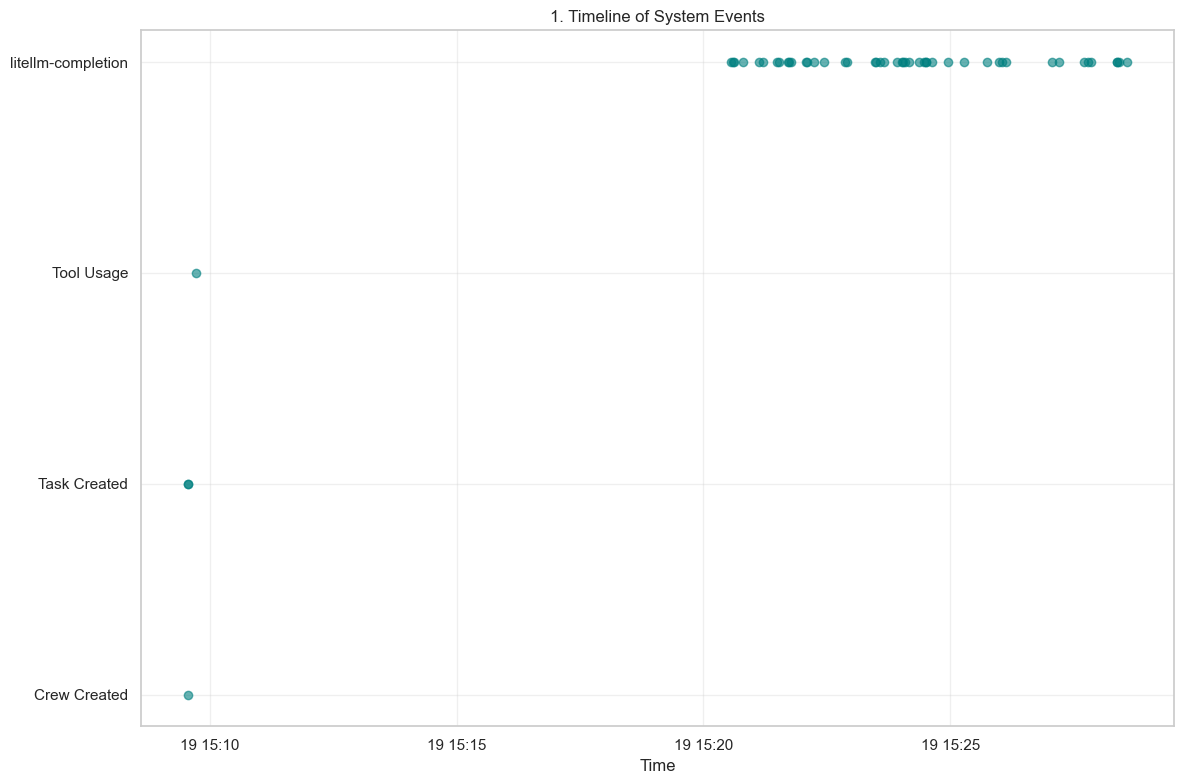

/var/folders/sc/shxd13rn0ll1ftvjm4r1pt_w0000gn/T/ipykernel_56311/1862017825.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=agent_counts.index, x=agent_counts.values, palette='viridis')


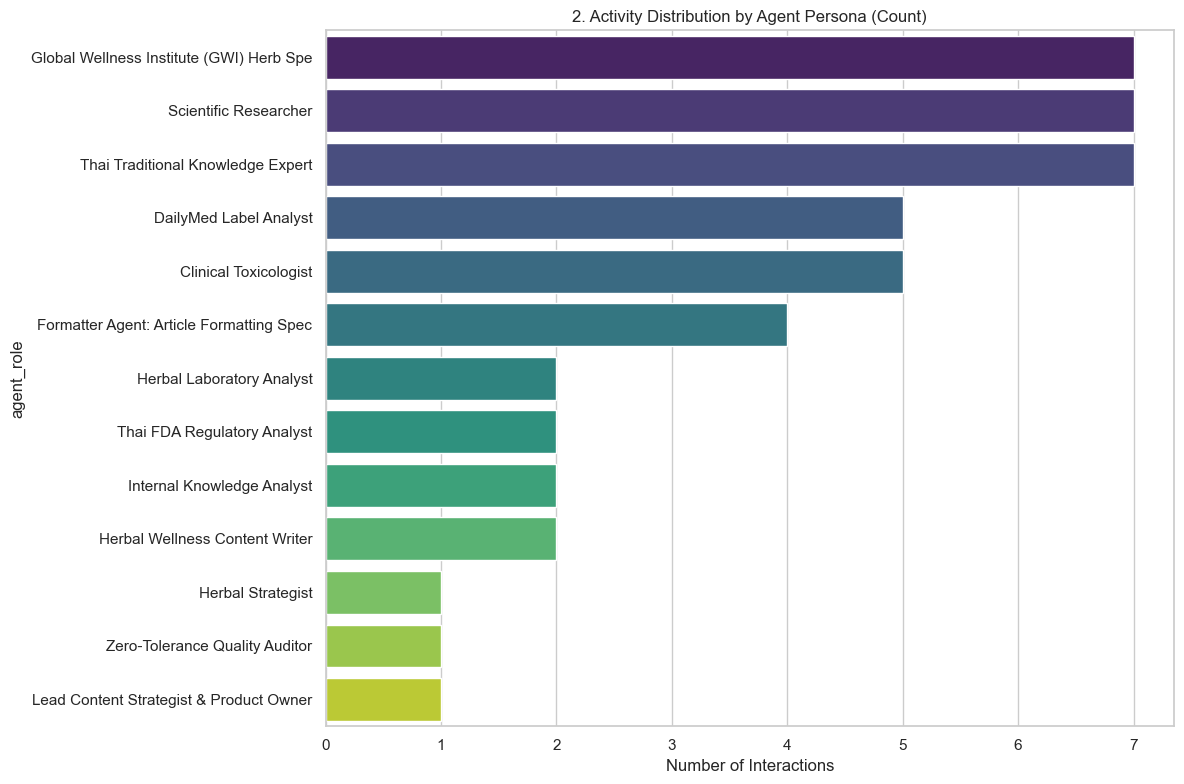

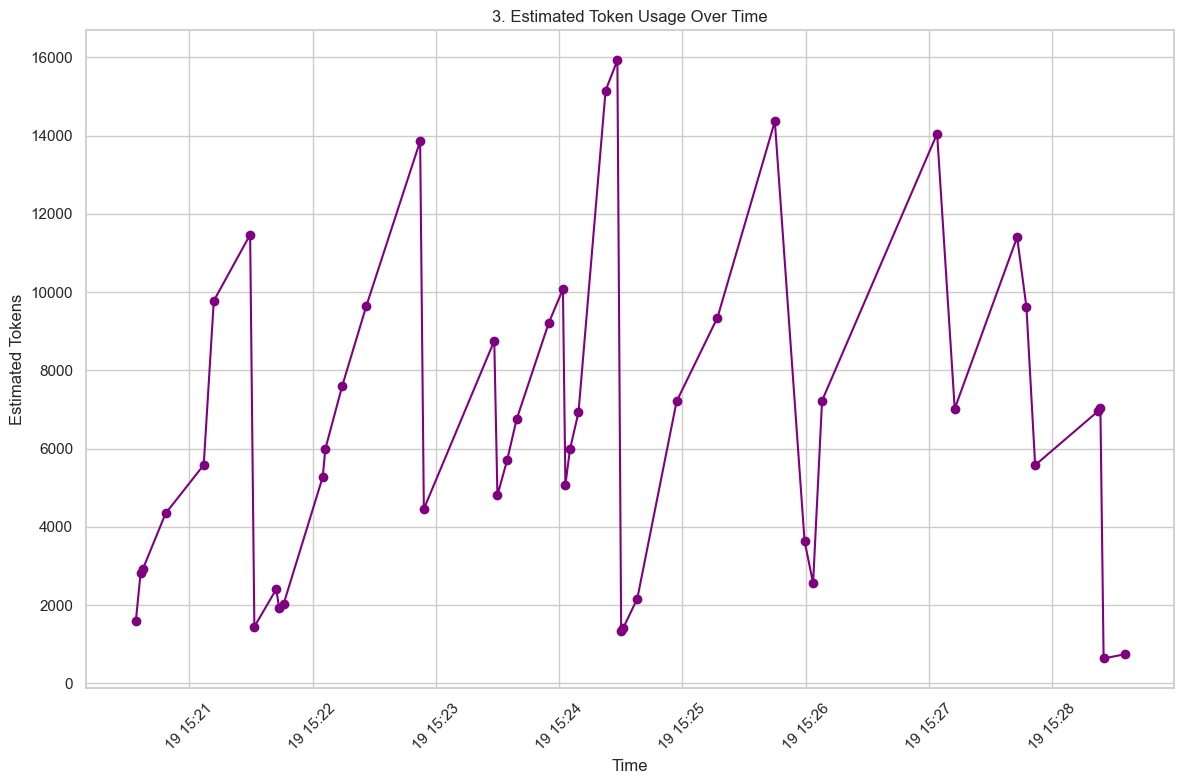

/var/folders/sc/shxd13rn0ll1ftvjm4r1pt_w0000gn/T/ipykernel_56311/1862017825.py:94: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df.set_index('timestamp').resample('1T').size().plot(kind='bar', color='skyblue')


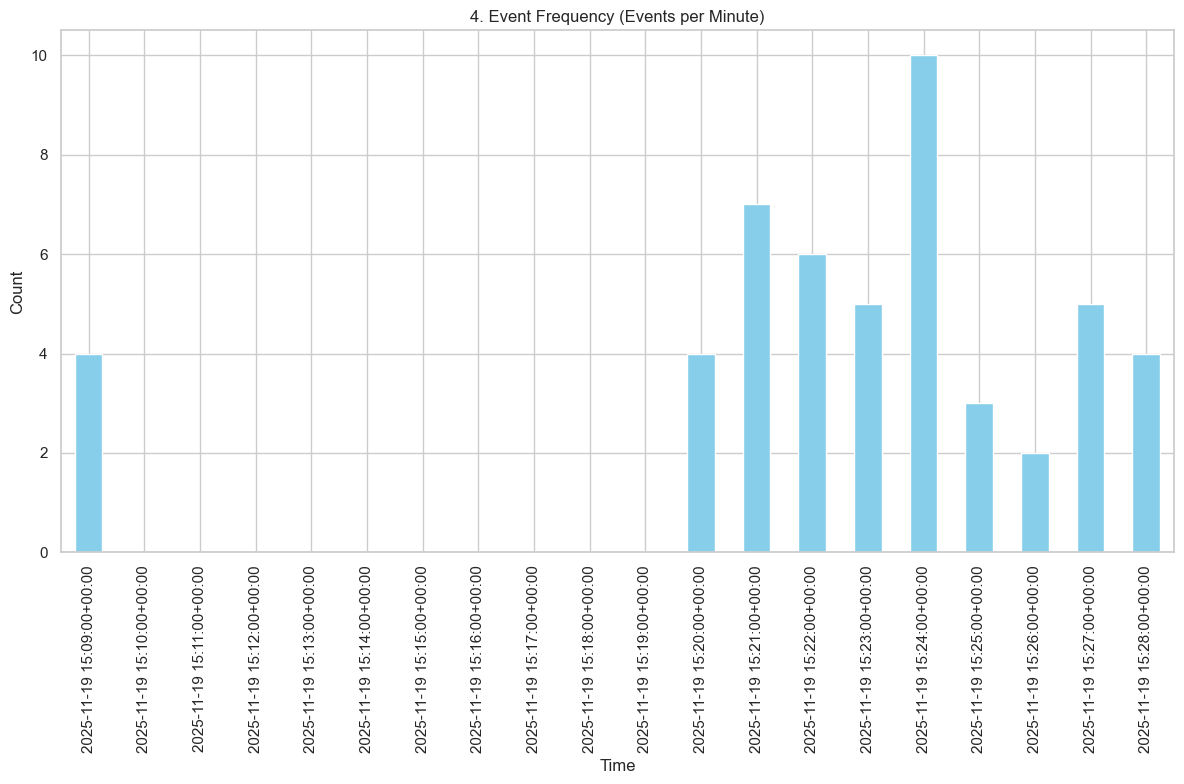

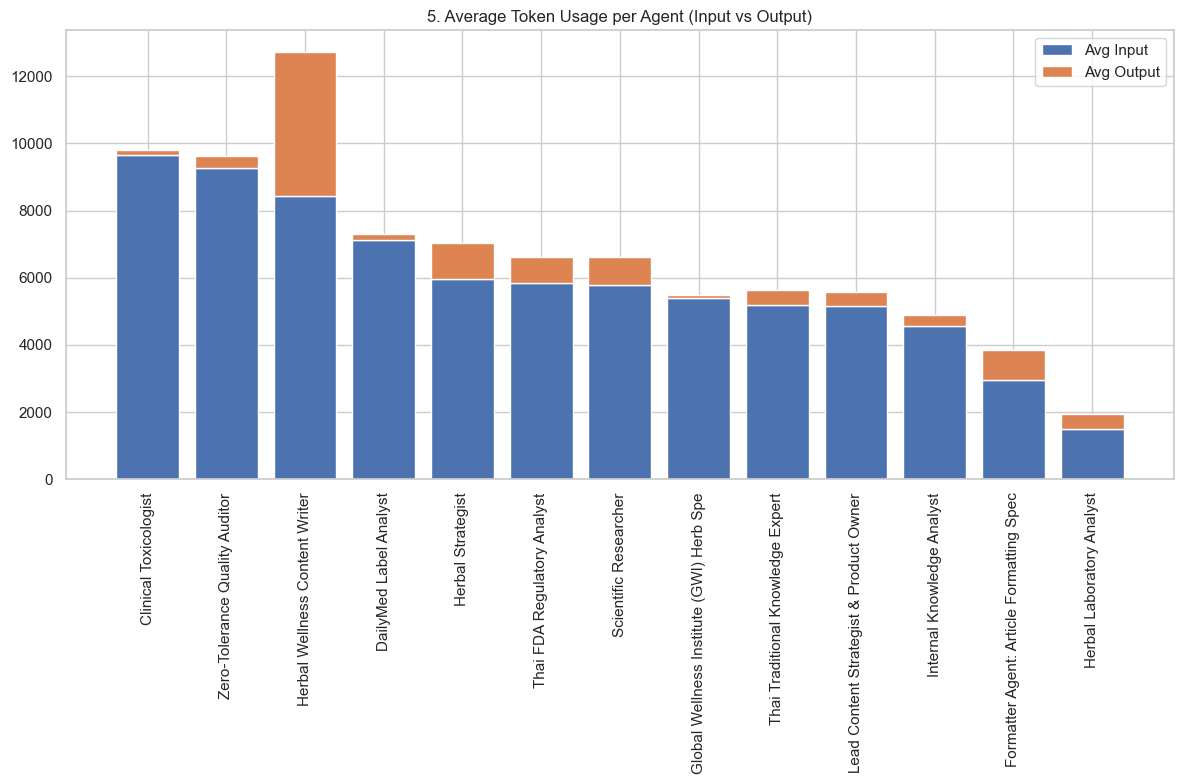

/var/folders/sc/shxd13rn0ll1ftvjm4r1pt_w0000gn/T/ipykernel_56311/1862017825.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='agent_role', y='duration_seconds', data=llm_df, palette="Set3")


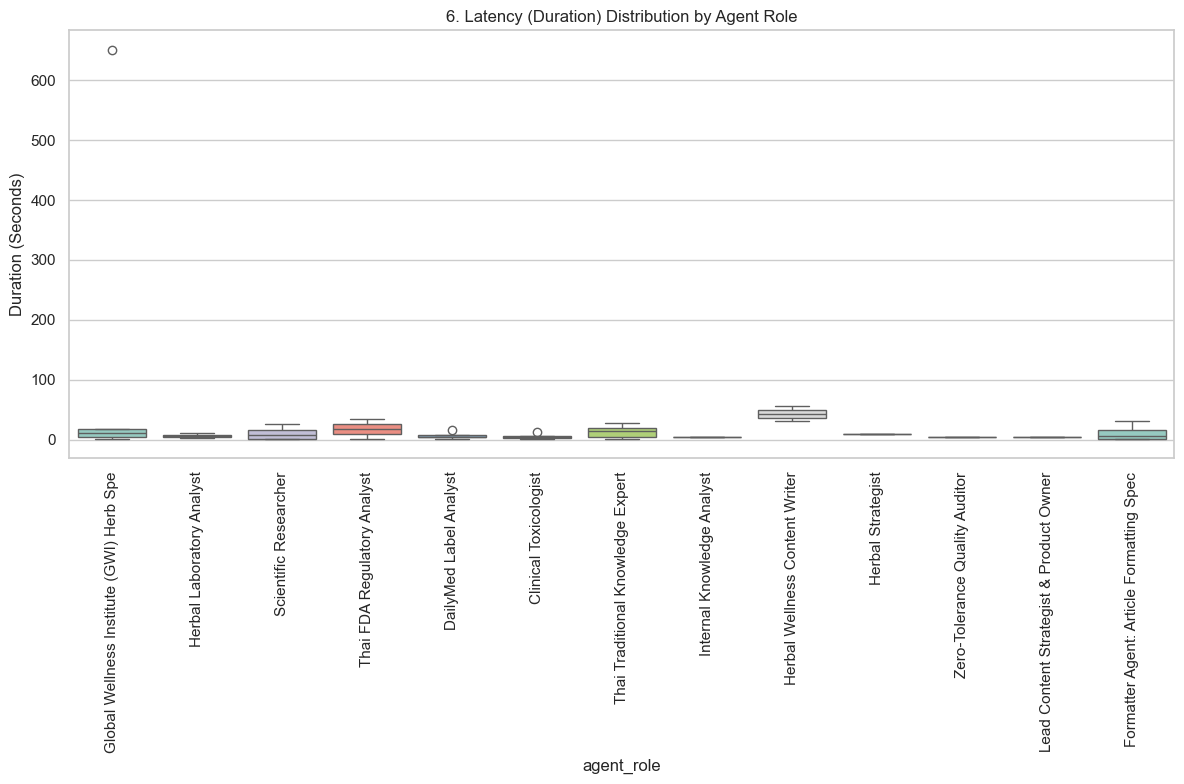

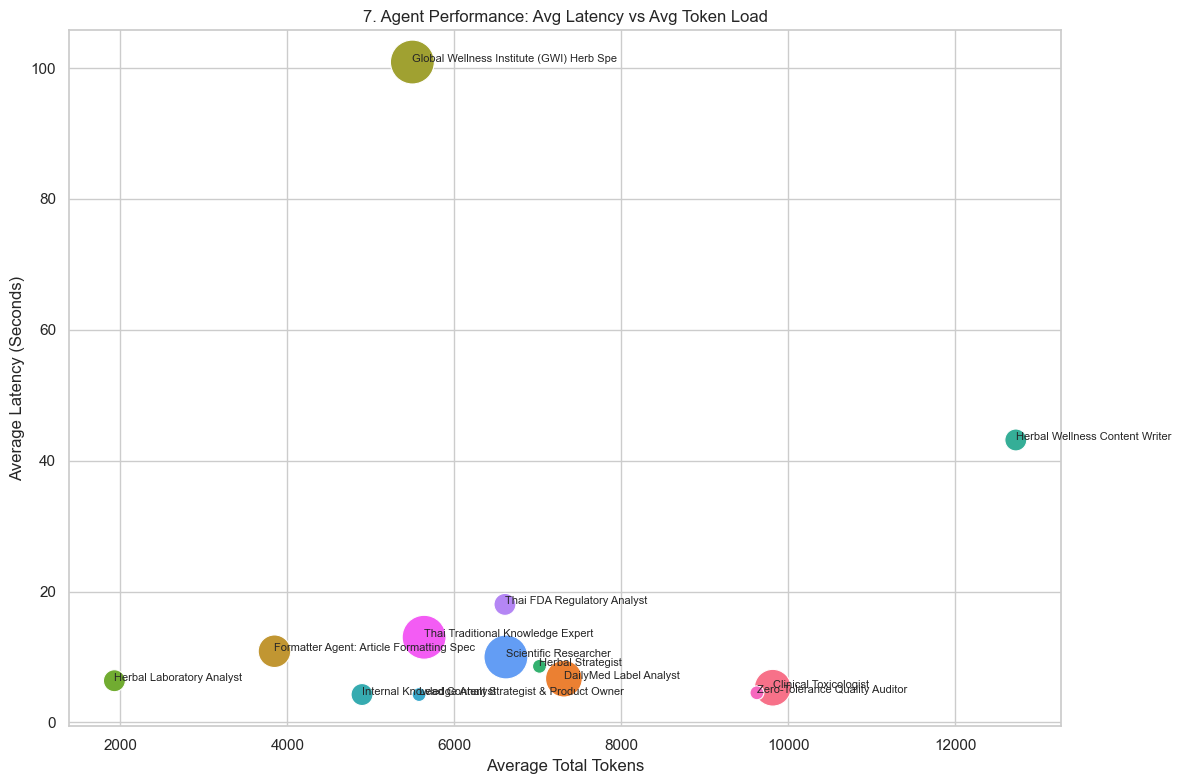

/var/folders/sc/shxd13rn0ll1ftvjm4r1pt_w0000gn/T/ipykernel_56311/1862017825.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='est_total_tokens', y='agent_role', data=role_sums, palette=colors)


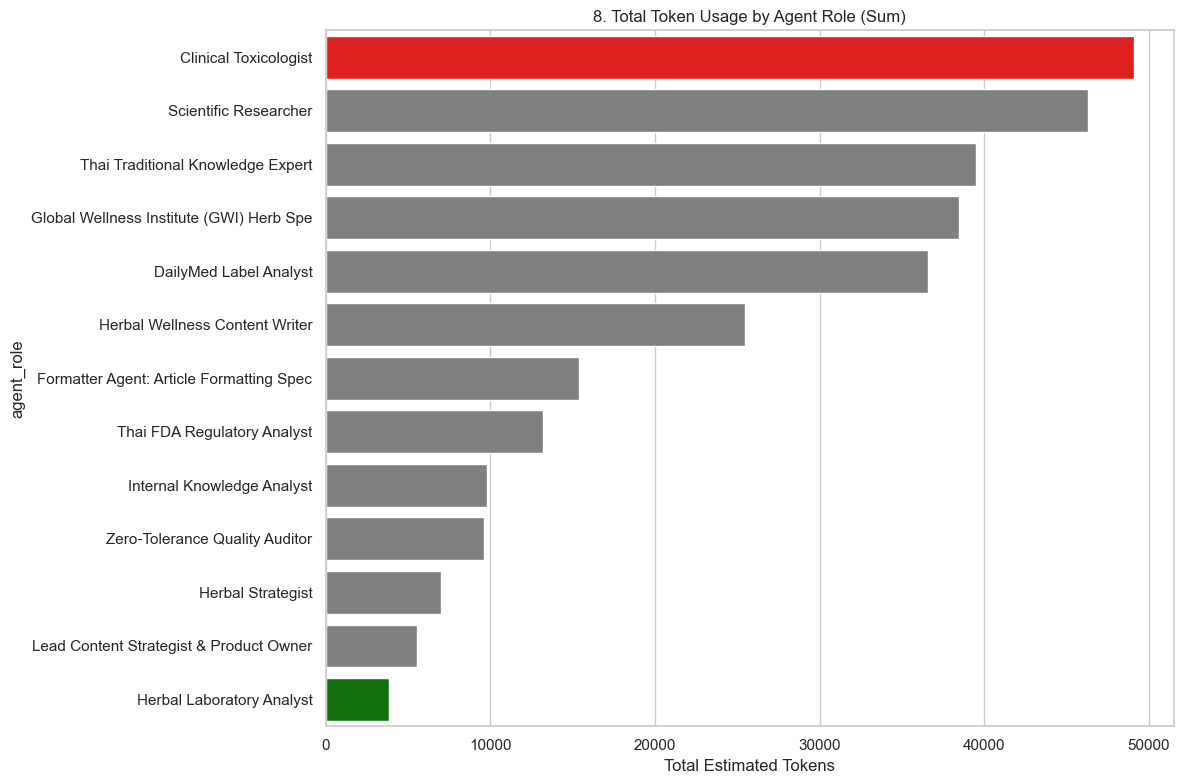

All visualizations generated successfully.


In [ ]:
# --- Main Execution ---
if __name__ == "__main__":
    file_name = '1763700679713-lf-traces-export-cmi632il0004wad07vu6l4fh6.csv'

    try:
        df_processed = load_and_process_data(file_name)
        plot_visualizations(df_processed)
        print("All visualizations generated successfully.")
    except FileNotFoundError:
        print("Error: File not found. Please check the filename.")

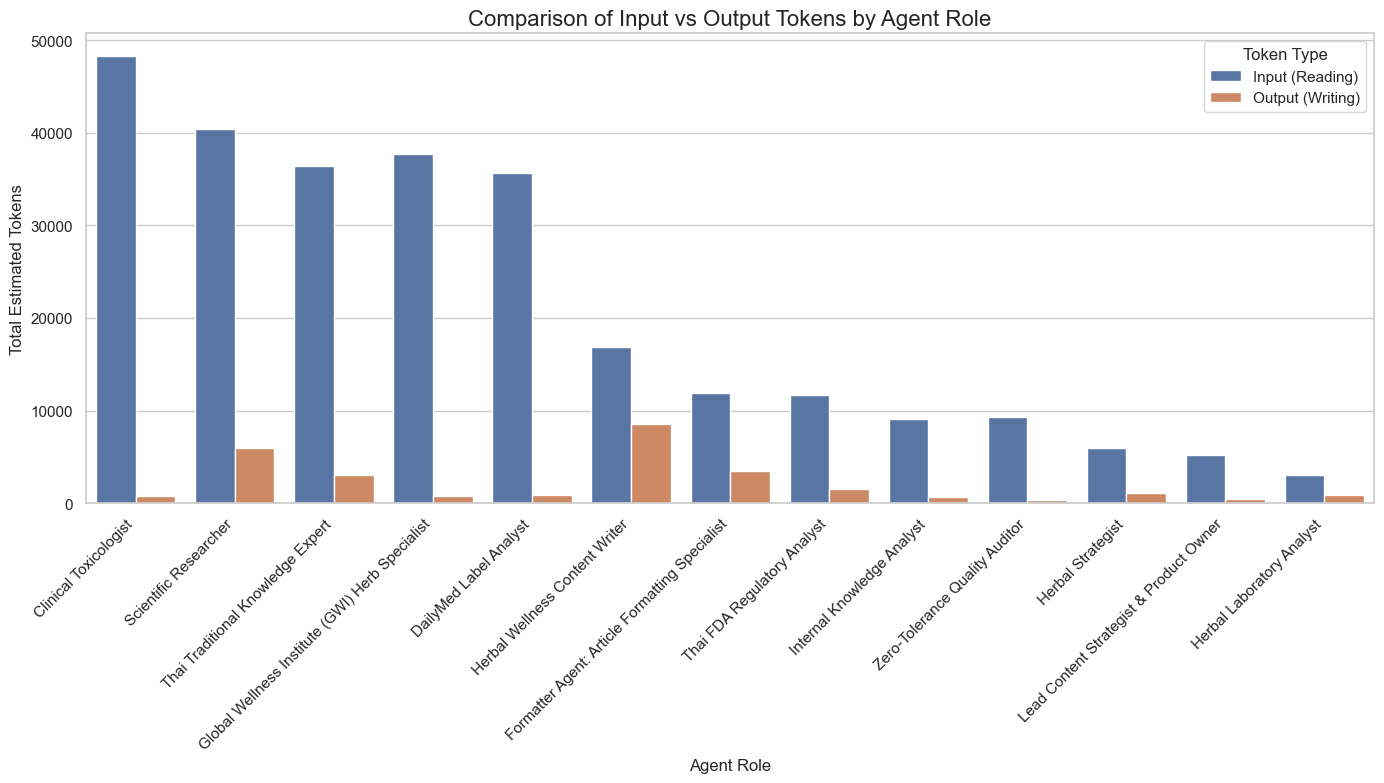

Graph created successfully.


In [ ]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

def plot_token_input_output_separated(file_path):
    df = pd.read_csv(file_path)

    # refine function to extract role and calculate tokens
    def process_row(row):
        agent_role = "Unknown"
        prompt_tokens = 0
        completion_tokens = 0

        if row['name'] == 'litellm-completion':
            # retrieve Role from JSON input
            if pd.notna(row['input']):
                try:
                    data = json.loads(row['input'])
                    if isinstance(data, str): data = json.loads(data)
                    if isinstance(data, dict) and 'messages' in data:
                        for msg in data['messages']:
                            if msg.get('role') == 'system':
                                content = msg.get('content', '')
                                if "You are" in content:
                                    agent_role = content.split("You are")[1].split("\n")[0].strip()
                                    agent_role = agent_role.replace("*", "").replace("#", "").strip()[:50]
                                break
                except:
                    pass

            # calculate Tokens (1 token ~ 4 chars)
            if pd.notna(row['input']):
                prompt_tokens = len(str(row['input'])) / 4
            if pd.notna(row['output']):
                completion_tokens = len(str(row['output'])) / 4

        return pd.Series([agent_role, prompt_tokens, completion_tokens])

    # process data
    df_llm = df[df['name'] == 'litellm-completion'].copy()
    df_llm[['agent_role', 'prompt_tokens', 'completion_tokens']] = df_llm.apply(process_row, axis=1)

    # filter out unknown roles
    df_llm = df_llm[df_llm['agent_role'] != "Unknown"]

    # 2. total tokens by role
    role_totals = df_llm.groupby('agent_role')[['prompt_tokens', 'completion_tokens']].sum().reset_index()

    # order by total tokens
    role_totals['total_tokens'] = role_totals['prompt_tokens'] + role_totals['completion_tokens']
    role_totals = role_totals.sort_values('total_tokens', ascending=False)

    # 3. transform data for plotting
    role_melted = role_totals.melt(
        id_vars='agent_role',
        value_vars=['prompt_tokens', 'completion_tokens'],
        var_name='Token Type',
        value_name='Token Count'
    )

    # customize Token Type names
    role_melted['Token Type'] = role_melted['Token Type'].map({
        'prompt_tokens': 'Input (Reading)',
        'completion_tokens': 'Output (Writing)'
    })

    # 4. Draw the graph
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")

    # Bar Chart
    chart = sns.barplot(
        x='agent_role',
        y='Token Count',
        hue='Token Type',
        data=role_melted,
        palette={'Input (Reading)': '#4c72b0', 'Output (Writing)': '#dd8452'} # กำหนดสีเองได้
    )

    plt.title('Comparison of Input vs Output Tokens by Agent Role', fontsize=16)
    plt.xlabel('Agent Role', fontsize=12)
    plt.ylabel('Total Estimated Tokens', fontsize=12)
    plt.xticks(rotation=45, ha='right') # เอียงชื่อแกน X
    plt.legend(title='Token Type')
    plt.tight_layout()

    plt.show()

if __name__ == "__main__":
    file_name = '1763700679713-lf-traces-export-cmi632il0004wad07vu6l4fh6.csv'
    try:
        plot_token_input_output_separated(file_name)
        print("Graph created successfully.")
    except FileNotFoundError:
        print("File not found.")

Reading data from: 1763700679713-lf-traces-export-cmi632il0004wad07vu6l4fh6.csv
Processing data...


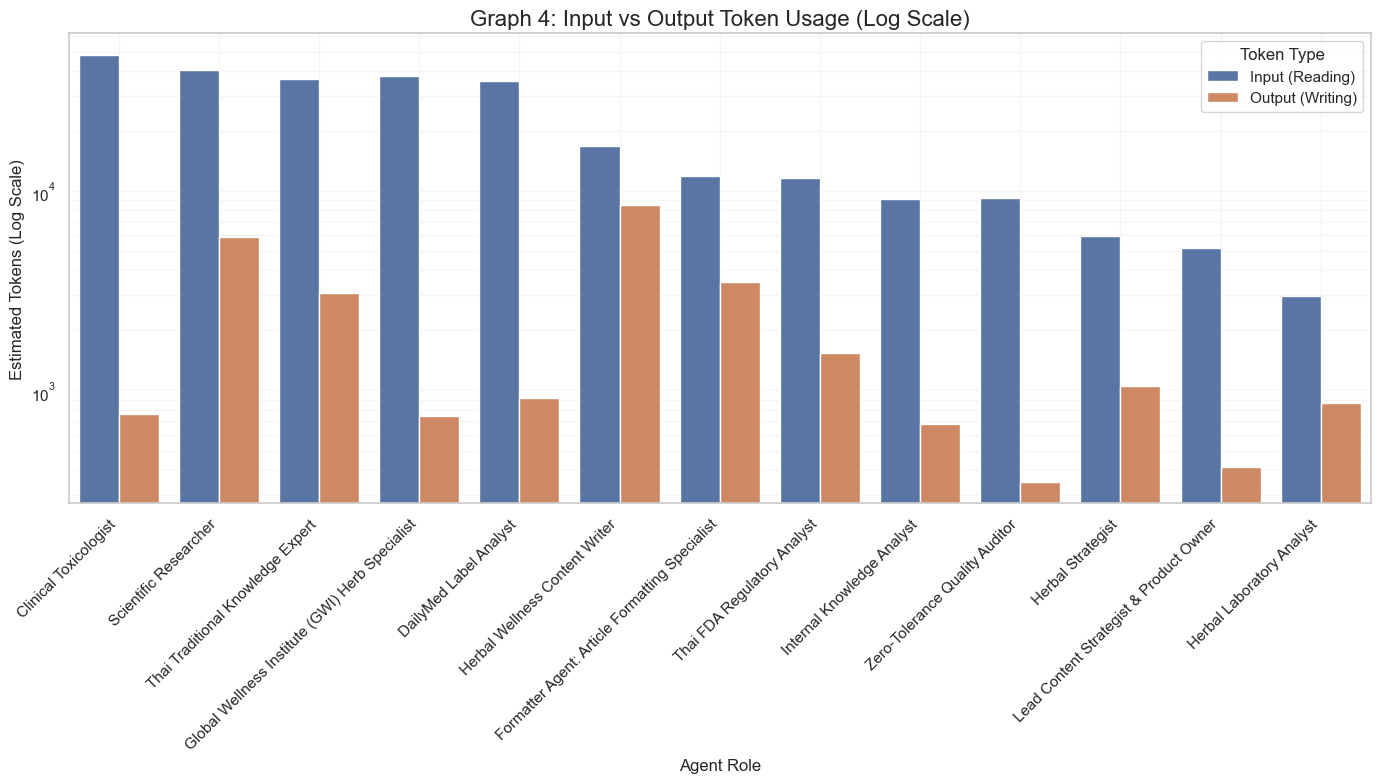

Graph 4 generated successfully.


In [ ]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

FILE_NAME = '1763700679713-lf-traces-export-cmi632il0004wad07vu6l4fh6.csv'

def generate_graph_4_log_scale(file_path):
    print(f"Reading data from: {file_path}")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print("Error: File not found.")
        return

    # --- 1. Data Extraction Logic ---
    print("Processing data...")

    def extract_details(row):
        agent_role = "Unknown"
        input_tokens = 0
        output_tokens = 0

        if row['name'] == 'litellm-completion':
            # Estimate Tokens
            if pd.notna(row['input']): input_tokens = len(str(row['input'])) / 4
            if pd.notna(row['output']): output_tokens = len(str(row['output'])) / 4

            # Find Agent Role
            if pd.notna(row['input']):
                try:
                    data = json.loads(row['input'])
                    if isinstance(data, str): data = json.loads(data)
                    if isinstance(data, dict) and 'messages' in data:
                        for msg in data['messages']:
                            if msg.get('role') == 'system' and "You are" in msg.get('content', ''):
                                role_part = msg['content'].split("You are")[1].split("\n")[0]
                                agent_role = role_part.replace("*", "").replace("#", "").strip()[:50]
                                break
                except: pass

        return pd.Series([agent_role, input_tokens, output_tokens])

    # Apply extraction
    df_llm = df[df['name'] == 'litellm-completion'].copy()
    df_llm[['agent_role', 'input_tokens', 'output_tokens']] = df_llm.apply(extract_details, axis=1)
    df_llm = df_llm[df_llm['agent_role'] != "Unknown"] # Filter unknowns

    # --- 2. Prepare Data for Plotting ---
    # Sum tokens per role
    role_sum = df_llm.groupby('agent_role')[['input_tokens', 'output_tokens']].sum().reset_index()

    # Sort by Total (Input + Output) for better visualization
    role_sum['total_sort'] = role_sum['input_tokens'] + role_sum['output_tokens']
    role_sum = role_sum.sort_values('total_sort', ascending=False)

    # Melt to Long Format (for Input/Output comparison)
    df_melt = role_sum.melt(id_vars='agent_role', value_vars=['input_tokens', 'output_tokens'],
                            var_name='Type', value_name='Tokens')

    # Rename for Legend
    df_melt['Type'] = df_melt['Type'].map({'input_tokens': 'Input (Reading)', 'output_tokens': 'Output (Writing)'})

    # --- 3. Plot Graph 4 (Log Scale) ---
    plt.figure(figsize=(14, 8))
    sns.set_theme(style="whitegrid")

    sns.barplot(x='agent_role', y='Tokens', hue='Type', data=df_melt, palette=['#4c72b0', '#dd8452'])

    # *** Log Scale Setting ***
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.2) # Detailed Grid

    plt.title('Graph 4: Input vs Output Token Usage (Log Scale)', fontsize=16)
    plt.ylabel('Estimated Tokens (Log Scale)', fontsize=12)
    plt.xlabel('Agent Role', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Token Type')
    plt.tight_layout()

    plt.show()
    print("Graph 4 generated successfully.")

if __name__ == "__main__":
    generate_graph_4_log_scale(FILE_NAME)

/var/folders/sc/shxd13rn0ll1ftvjm4r1pt_w0000gn/T/ipykernel_56311/3079252405.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='agent_role', y='duration_seconds', data=df_plot, order=order, palette="Set3", showfliers=False)


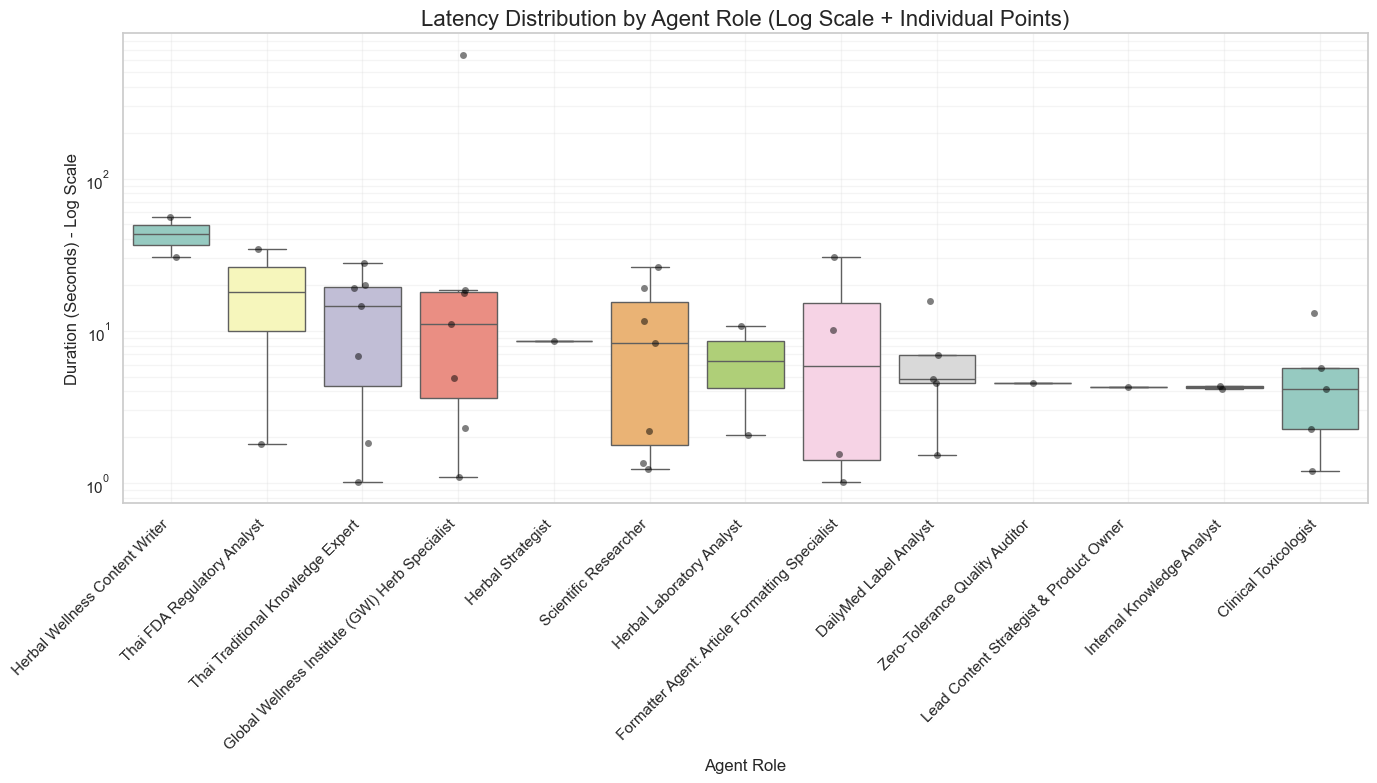

In [ ]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

def generate_detailed_latency_boxplot(file_path):
    # 1. Load & Process Data
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp')

    # Calculate Duration
    df['prev_timestamp'] = df['timestamp'].shift(1)
    df['duration_seconds'] = (df['timestamp'] - df['prev_timestamp']).dt.total_seconds()
    df['duration_seconds'] = df['duration_seconds'].fillna(0)

    # Extract Role
    def get_role(row):
        if row['name'] == 'litellm-completion' and pd.notna(row['input']):
            try:
                d = json.loads(row['input'])
                if isinstance(d, str): d = json.loads(d)
                if 'messages' in d:
                    for m in d['messages']:
                        if m.get('role') == 'system' and "You are" in m.get('content', ''):
                            return m['content'].split("You are")[1].split("\n")[0].strip().replace("*", "")[:50]
            except: pass
        return "Unknown"

    df['agent_role'] = df.apply(get_role, axis=1)
    df_plot = df[(df['name'] == 'litellm-completion') & (df['agent_role'] != "Unknown")]

    # 2. Plotting
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")

    # Sort order by Median Latency
    order = df_plot.groupby('agent_role')['duration_seconds'].median().sort_values(ascending=False).index

    # Box Plot
    sns.boxplot(x='agent_role', y='duration_seconds', data=df_plot, order=order, palette="Set3", showfliers=False)

    # Add Individual Points (Jitter)
    sns.stripplot(x='agent_role', y='duration_seconds', data=df_plot, order=order, color='black', alpha=0.5, jitter=True)

    # Log Scale & Grid
    plt.yscale('log')
    plt.grid(True, which="both", ls="-", alpha=0.2)

    plt.title('Latency Distribution by Agent Role (Log Scale + Individual Points)', fontsize=16)
    plt.ylabel('Duration (Seconds) - Log Scale', fontsize=12)
    plt.xlabel('Agent Role', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.show()

# Run
if __name__ == "__main__":
    generate_detailed_latency_boxplot('1763700679713-lf-traces-export-cmi632il0004wad07vu6l4fh6.csv')